# Import Rideshare Data

In [2]:
import datetime

import matplotlib
import numpy as np
import pandas as pd

Uncomment this cell to run (1-5 min):

Reccomend that you have 16gb storage on your computer to run this

In [3]:
df = pd.read_csv("~/Downloads/tnp.csv")

/var/folders/85/f68ppp2j4cg5ykw_cvg3t4gw0000gn/T/ipykernel_80502/1247983384.py:1: DtypeWarning: Columns (0: Trip Miles) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("~/Downloads/tnp.csv")


Select only the columns we want and store as `share`: 

In [4]:
master_share = df[
    [
        "Trip ID",
        "Trip Start Timestamp",
        "Trip End Timestamp",
        "Trip Seconds",
        "Trip Miles",
        "Percent Time Chicago",
        "Percent Distance Chicago",
        "Pickup Census Tract",
        "Dropoff Census Tract",
        "Fare",
        "Tip",
        "Additional Charges",
        "Trip Total",
        "Pickup Centroid Latitude",
        "Pickup Centroid Longitude",
        "Dropoff Centroid Latitude",
        "Dropoff Centroid Longitude",
    ]
]

share = master_share

In [5]:
# Should have 31146361 or 93510249 rows
len(share)

93510249

## Clean data

First on the cleaning agenda:
    There are some percentage (time and distance) that are greater than 100.
    Let's see how many of those there are and decide what to do about those.

2 options:
    a) delete them
    b) Check if lat and long start and end are both in chicago, if so keep, else delete

Convert percntages into a usable datatype, int (20-30s):
(For this conversion to work, first we need to remove rows with missing values if this hasn't already been done - this cell took 3 minutes in total to run with a longer start csv.)

In [6]:
share = share.dropna(subset=["Percent Time Chicago", "Percent Distance Chicago"])

share["Int Percent Time Chicago"] = (
    share["Percent Time Chicago"].str.replace("%", "").str.replace(",", "")
).astype(int)

share["Int Percent Distance Chicago"] = (
    share["Percent Distance Chicago"].str.replace("%", "").str.replace(",", "")
).astype(int)

In [9]:
# No filters run here, just exploratory counts.

time_over = (share["Int Percent Time Chicago"] > 100).sum()
time_in = (share["Int Percent Time Chicago"] == 100).sum()

dist_over = (share["Int Percent Distance Chicago"] > 100).sum()
dist_in = (share["Int Percent Distance Chicago"] == 100).sum()

print(
    f"{time_over} rows have a percentage of time over 100%, compared to {time_in} that are normal\nso unrealistic percentages make up {round(time_over * 100 / (time_over + time_in), 3)}% of the dataset"
)

print(
    f"{dist_over} rows have a percentage of distance over 100%, compared to {dist_in} that are normal\nso unrealistic percentages make up {round(dist_over * 100 / (dist_over + dist_in), 3)}% of the dataset"
)

26212 rows have a percentage of time over 100%, compared to 71546087 that are normal
so unrealistic percentages make up 0.037% of the dataset
22598 rows have a percentage of distance over 100%, compared to 60202904 that are normal
so unrealistic percentages make up 0.038% of the dataset


Because the percentage of the data that has unrealistic time or duration percentages is relativley low, for simplicity's sake we're just going to remove those rows from the dataset for this round of exploration.

In [7]:
before_len = len(share)
print(
    f"Before removing rows with unlikely time/distance percentages, we have {before_len} rows in the dataset"
)

#  Save a copy of the data before removing rows, in case we want to come back to it
share_with_perc = share

Before removing rows with unlikely time/distance percentages, we have 93106410 rows in the dataset


(15-20s if csv is filtered on percent time and percent distance, 4.5 mins if not)

In [8]:
share = share[share["Int Percent Time Chicago"] == 100]
share = share[share["Int Percent Distance Chicago"] == 100]

after_len = len(share)
print(
    f"We are left with {after_len} rows in the dataset, having removed {before_len - after_len}"
)

We are left with 57725849 rows in the dataset, having removed 35380561


Remove percentage time and percentage distance cols as that's no longer relevant.  Let's take a look at the data.

In [9]:
share = share[
    [
        "Trip ID",
        "Trip Start Timestamp",
        "Trip End Timestamp",
        "Trip Seconds",
        "Trip Miles",
        "Pickup Census Tract",
        "Dropoff Census Tract",
        "Fare",
        "Tip",
        "Additional Charges",
        "Trip Total",
        "Pickup Centroid Latitude",
        "Pickup Centroid Longitude",
        "Dropoff Centroid Latitude",
        "Dropoff Centroid Longitude",
    ]
]
share_before_nan_drop = share

Replace string "NaN" to true null `np.nan` (10-40) Dropping all NAs took about 2 minutes.

In [10]:
share = share.replace("NaN", np.nan)
share = share.dropna()

Next, we ensure that all trips in the dataframe start and end within calendar year 2025. 

In [11]:
share["Trip Start Timestamp"] = pd.to_datetime(
    share["Trip Start Timestamp"], format="%m/%d/%Y %I:%M:%S %p"
)
share["Trip End Timestamp"] = pd.to_datetime(
    share["Trip End Timestamp"], format="%m/%d/%Y %I:%M:%S %p"
)
share = share[share["Trip Start Timestamp"] >= "01/01/2025 12:00:00 AM"]
share = share[share["Trip End Timestamp"] <= "12/31/2025 11:59:59 PM"]

In [12]:
clean_share = share
print(f"After basic cleaning, we are left with {len(share)} rows")

# Sabrina: 19264104
# Molly: 38002687

After basic cleaning, we are left with 38055762 rows


## Testing

### Checking for duplicate IDs

Molly and Sabrina have different length datasets after cleaning - use the following cell to check for duplicate ride IDs.

In [13]:
a = len(clean_share)
b = len(clean_share["Trip ID"].drop_duplicates())
print(f"There are {a - b} duplicate cells.")

There are 0 duplicate cells.


## Paring Down

At this point I would consider the  most basic level of cleaning done.  Next we do exploration and figure out how to dramatically par down our data while still preserving the nature of the data

Potential paths:

- Acccording to google, 2-3 decimal places is 1.1km to 111m precision. We definitley do not want to be more granular than 3 decimals, but curious to see how much dropping from 3 to 2 decimal places reduces the start/stop pairs we need to make api calls for.
- How much census tract data is missing? (JK after the NaN cleaning step we should only have complete data)
- How much data is in 1 week? 1 month?
- Should we randomly select 100,000 rows ??

### Clustering by coarse lat/long

How many unique start and end lat/long pairs exist if we truncate to 3 decimal points? 

In [14]:
clustered = clean_share

clustered["Pickup Centroid Latitude"] = clustered["Pickup Centroid Latitude"].round(3)
clustered["Pickup Centroid Longitude"] = clustered["Pickup Centroid Longitude"].round(3)
clustered["Dropoff Centroid Latitude"] = clustered["Dropoff Centroid Latitude"].round(3)
clustered["Dropoff Centroid Longitude"] = clustered["Dropoff Centroid Longitude"].round(
    3
)

unique_combos = clustered[
    [
        "Pickup Centroid Latitude",
        "Pickup Centroid Longitude",
        "Dropoff Centroid Latitude",
        "Dropoff Centroid Longitude",
    ]
].drop_duplicates()
print(
    f"After rounding to 3 decimal points (~111m), we are left with {len(unique_combos)} unique pickup-dropoff pairs."
)

After rounding to 3 decimal points (~111m), we are left with 397536 unique pickup-dropoff pairs.


Exploratory extension: If we just look at one week of data?

In [33]:
one_week = clustered[clustered["Trip Start Timestamp"] >= "03/24/2025 12:00:00 AM"]
one_week = one_week[one_week["Trip Start Timestamp"] <= "03/31/2025 12:00:00 AM"]
unique_combos = one_week[
    ["Pickup Census Tract", "Dropoff Census Tract"]
].drop_duplicates()
print(
    f"After rounding to 3 decimal points (~111m) and selecting one week of data, we are left with {len(unique_combos)} unique pickup-dropoff pairs."
)
print(f"One week of data is {len(one_week)} rows.")

KeyboardInterrupt: 

### Clustering by hour

After clustering a little coarsely by location, the unique trip paths still differ by time. The same start point and destination will have different transit alternatives depending on the time of day. WHen we round to 3 decimal points and round ride start time to the nearest hour, we are left with X unique trips. If we remove date from the equation and just look at days of the week (weekday = 0, Saturday = 1, Sunday = 2), we are left with X unique trips. (For purposes of this cell, a unique trip is a unique day of week or date/time/start point/end point combination, and there may be multiple individual rides wihin each trip.)

In [15]:
clustered["start_hour"] = clustered["Trip Start Timestamp"].dt.hour
wd = clustered["Trip Start Timestamp"].dt.weekday
clustered["day_type"] = (wd == 5).astype(int) + (wd == 6).astype(int) * 2

unique_combos = clustered[
    [
        "Pickup Centroid Latitude",
        "Pickup Centroid Longitude",
        "Dropoff Centroid Latitude",
        "Dropoff Centroid Longitude",
        "start_hour",
        "day_type",
    ]
].drop_duplicates()
f"There are {len(unique_combos)} unique transit API calls in the full dataset."

'There are 4927129 unique transit API calls in the full dataset.'

## Toy Dataset
Pulling 100 random rows from the clustered dataset, which features no NA entries, truncated coordinates, and options to use coarser start_hour and day_of_week time fields instead of the default start and end timestamps.

In [16]:
toy_data = clustered.sample(100, random_state=42)
toy_data.to_csv("toy_data.csv", index=False)

## Project Dataset
To ensure we only have 100,000 API calls, I grouped data by unique trip characteristics (day type, start hour, pickup coordinates, and dropoff coordinates) and created new "group_id" and "group_n" variables. group_n shows how many individual rides fall in that group. group_id allows us to match API calls back to the long dataset. Here, I create the compressed dataset and add the group ids back to our long dataframe.

In [17]:
group_cols = [
    "day_type",
    "start_hour",
    "Pickup Centroid Latitude",
    "Pickup Centroid Longitude",
    "Dropoff Centroid Latitude",
    "Dropoff Centroid Longitude",
]

compressed = clustered.groupby(group_cols).size().reset_index(name="group_n")

compressed["group_id"] = compressed.index

clustered = clustered.merge(
    compressed[group_cols + ["group_id"]], on=group_cols, how="left"
)

Now, I create csv files with 100,000 randomly pulled unique trips from the compressed dataframe and the corresponding rows of the clustered dataframe. If we'd like, instead of pulling random rows we could pull the most common rows.

In [19]:
grouped_100k = compressed.sample(100000, random_state=888)
grouped_100k.to_csv("grouped_100k.csv", index=False)

sample_ids = grouped_100k["group_id"]
clustered_subset = clustered[clustered["group_id"].isin(sample_ids)]
clustered_subset.to_csv("longdata_100k.csv", index=False)

### Removing unnecessarily expensive rides

Total trip cost to float

In [42]:
share["Int Total"] = (
    share["Trip Total"].str.replace("$", "").str.replace(",", "")
).astype(float)

Can we exclude extremely expensive rides?

In [43]:
share.sort_values(by="Int Total", ascending=False).head()

KeyboardInterrupt: 

<Axes: >

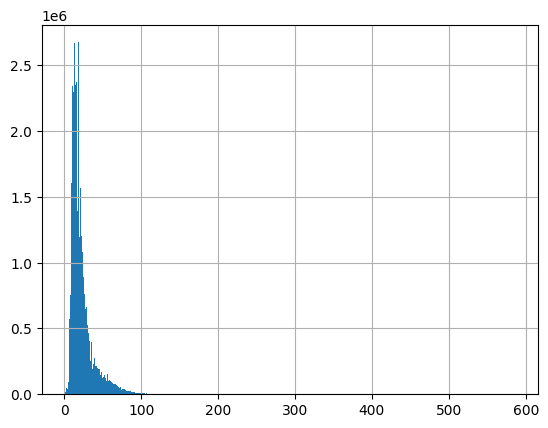

In [ ]:
share["Int Total"].hist(bins=500)

Number of rides that are over $100:

In [ ]:
(share["Int Total"] > 100).sum()

np.int64(62351)